# Ch01 데이터

- 데이터 크기

In [2]:
# 표 데이터 처리에 특화된 통계분석 lib -> pandas
import pandas as pd

# csv 파일 읽어오기
df = pd.read_csv('../통계분석2/받은 파일/data/ch1_sport_test.csv', index_col = '학생번호')
df

,학년,악력,윗몸일으키기,점수,순위
학생번호,,,,,
1,1,40.2,34,15,4
2,1,34.2,14,7,10
3,1,28.8,27,11,7
4,2,39.0,27,14,5
5,2,50.9,32,17,2
6,2,36.5,20,9,9
7,3,36.6,31,13,6
8,3,49.2,37,18,1
9,3,26.0,28,10,8


In [ ]:
# 열 추출 -> Series 반환
df['악력']

학생번호
1     40.2
2     34.2
3     28.8
4     39.0
5     50.9
6     36.5
7     36.6
8     49.2
9     26.0
10    47.4
Name: 악력, dtype: float64

In [4]:
# shape -> 튜플 형태로 (행 개수, 열 개수)를 반환
df.shape

(10, 5)

- 변수 종류

In [ ]:
# 질적 변수: 값이 대상의 종류, 속성, 범주를 구분하는 것
# 양적 변수: 값이 수치값, 크기 비교나 산술 연산이 가능함

# 이산형 변수: 각 개개의 값 취하는 변수, 인접한 사이에 숫자 존재함
# 연속형 변수: 연속적인 값 취하는 변수, 인접한 사이에 숫자 반드시 존재

# Ch02 1차원 데이터

- 데이터 중심 지표

In [ ]:
import numpy as np
import pandas as pd

# 주피터 노트북의 출력을 소수점 3자리 이하로 제한
%precision 3

# pd.set_option('precision', 3) -> pandas 업데이트로 이제 쓸 수 없음
pd.set_option('display.precision', 3)
pd.set_option('display.float_format', '{:.3f}'.format) # 둘 다 됨

In [3]:
df = pd.read_csv('../통계분석2/받은 파일/data/ch2_scores_em.csv', index_col = 'student number')
df.head()

,english,mathematics
student number,,
1,42,65
2,69,80
3,56,63
4,41,63
5,57,76


In [4]:
scores = np.array(df['english'])[:10]

scores_df = pd.DataFrame({'score': scores}, index = pd.Index(['A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'J'], name = 'student'))
scores_df

,score
student,
A,42
B,69
C,56
D,41
E,57
F,48
G,65
H,49
I,65


In [12]:
# 평균값 : 데이터 모두 더한 값 / 데이터 개수
print(sum(scores)/len(scores))
print(np.mean(scores))
print(scores_df.mean())

55.0
55.0
score    55.0
dtype: float64


In [ ]:
# 중앙값 : 데이터를 크기 순으로 나열할 때 정중앙인 값. 이상값에 영향 덜 받음
# 홀수일 때 -> (n + 1) / 2
# 짝수일 때 -> n / 2와 n / 2 + 1의 평균값
sorted_scores = np.sort(scores)
sorted_scores

array([41, 42, 48, 49, 56, 57, 58, 65, 65, 69])

In [15]:
n = len(sorted_scores)
if n % 2 == 0:
    m0 = sorted_scores[n//2 - 1]
    m1 = sorted_scores[n//2]
    median = (m0 + m1) / 2
else:
    median = sorted_scores[(n+1)//2 - 1]
median

56.500

In [ ]:
# 절사평균 : 양쪽 좀 자르고 나머지의 평균. 이상값에 영향 거의 안받음
# (+) 정보 손실 적다
# 예> 20% 절사평균 -> 20개 자료 중 양쪽 2개씩 총 4개 빼고 16개의 평균

In [16]:
# 최빈값 : 데이터에서 가장 많이 나타난 값
pd.Series([1,1,1,2,2,3]).mode()

0    1
dtype: int64

- 데이터 산포도 지표

In [ ]:
# 편차 : 각 데이터가 평균으로부터 떨어진 정도
mean = np.mean(scores)
dev = scores - mean
dev

# 편차 비교 : 어떤 편찻값과 편차 평균을 비교하는 것
# 편차 평균은 0
sum_df = scores_df.copy()
sum_df['dev'] = dev
sum_df

,score,dev
student,,
A,42,-13.0
B,69,14.0
C,56,1.0
D,41,-14.0
E,57,2.0
F,48,-7.0
G,65,10.0
H,49,-6.0
I,65,10.0


In [19]:
sum_df.mean()

score    55.0
dev       0.0
dtype: float64

In [22]:
# (모)분산 : 편차의 제곱 평균
print(np.mean(dev ** 2))
print(np.var(scores))

# 표본분산 : Series의 var 메서드는 불편분산,
#           Pandas(DataFrame)의 표본분산은 var 메서드의 인수 ddof = 0

# 분산은 Numpy로 계산, sum_df에 편차의 제곱 열 추가
sum_df['dev**2'] = np.square(dev)
sum_df

86.0
86.0


,score,dev,dev**2
student,,,
A,42,-13.0,169.0
B,69,14.0,196.0
C,56,1.0,1.0
D,41,-14.0,196.0
E,57,2.0,4.0
F,48,-7.0,49.0
G,65,10.0,100.0
H,49,-6.0,36.0
I,65,10.0,100.0


In [23]:
sum_df.mean()

score     55.0
dev        0.0
dev**2    86.0
dtype: float64

In [ ]:
# 표준편차 : 분산의 제곱근
#           원래 데이터와 동일 단위이므로 동일 차원
print(np.sqrt(np.var(scores, ddof = 0)))
print(np.std(scores, ddof = 0))

9.273618495495704
9.273618495495704


In [26]:
# 범위 : 최댓값 - 최솟값으로 산포도 표현
np.max(scores) - np.min(scores)

np.int64(28)

In [27]:
# 사분위 범위 : 상위수%와 하위수%에 위치하는 값 차이
# 데이터 하위 각 25%, 50%, 75% -> Q1, Q2, Q3
# 사분위 범위 : IQR = Q3 - Q1
scoresQ1 = np.percentile(scores, 25)
scoresQ3 = np.percentile(scores, 75)
IQR = scoresQ3 - scoresQ1
IQR

15.000

In [28]:
pd.Series(scores).describe()

count    10.000
mean     55.000
std       9.775
min      41.000
25%      48.250
50%      56.500
75%      63.250
max      69.000
dtype: float64

- 정규화

In [35]:
# 표준화 : 상대적 결과를 통일된 지표로 변환해 표현하는 것
#         데이터에서 평균 빼고 표준편차로 나누는 작업
#         표준화된 데이터는 표준화 변량 or Z점수
z = (scores - np.mean(scores)) / np.std(scores)
print("z > ", z)

print("np.mean(z) > ", np.mean(z)) #평균 = 0
print("np.std(z, ddof = 0) > ", np.std(z, ddof = 0)) #표준편차 = 1

np.mean(z), np.std(z, ddof = 0)

z >  [-1.402  1.51   0.108 -1.51   0.216 -0.755  1.078 -0.647  1.078  0.323]
np.mean(z) >  -1.6653345369377347e-17
np.std(z, ddof = 0) >  0.9999999999999999


(-0.000, 1.000)

In [39]:
# 편찻값 : 평균은 50, 표준편차는 10이 되도록 정규화한 값
z2 = 50 + 10 * (scores - np.mean(scores)) / np.std(scores)
print("z2 > ", z2)

# 점수와 편찻값의 관계
scores_df['dev value'] = z2
scores_df

z2 >  [35.982 65.097 51.078 34.903 52.157 42.452 60.783 43.53  60.783 53.235]


,score,dev value
student,,
A,42,35.982
B,69,65.097
C,56,51.078
D,41,34.903
E,57,52.157
F,48,42.452
G,65,60.783
H,49,43.530
I,65,60.783


- 1차원 데이터 시각화

In [40]:
# 50명의 영어 점수 배열
eng_scores = np.array(df['english'])
pd.Series(eng_scores).describe()

count    50.00
mean     58.38
std       9.80
min      37.00
25%      54.00
50%      57.50
75%      65.00
max      79.00
dtype: float64

예제 문제 : 준수네 반 학생들 중 50kg 미만이 전체의 몇 %인가?
- 답: 5 / 20 = 25%

In [44]:
# 도수분포표 : 데이터 분포 상태를 세부적으로 분포값으로 알고싶을 때 세는 방법.
#             데이터를 구간별로 나누고, 각 구간의 데이터 개수를 셈

# (예를 들어)
# - 계급 : 시험 점수를 10점 간격으로 나눌 때 0~10점 구간
# - 도수 : 각 계급에 속한 사람 수
# - 계급폭 : 구간의 폭, 0~10점의 경우 계급폭은 10점
# - 계급수 : 계급 개수, 10개(0~100점 사이 10점씩이니까)
freq, _ = np.histogram(eng_scores, bins = 10, range = (0, 100))
freq

array([ 0,  0,  0,  2,  8, 16, 18,  6,  0,  0])

In [45]:
# 0~10, 10~20, ... 이라는 문자열 리스트
freq_cls = [f'{i} ~ {i+10}' for i in range(0, 100, 10)]

#freq_cls를 인덱스로 DataFrame 작성
freq_dist_df = pd.DataFrame({'frequency' : freq}, index = pd.Index(freq_cls, name = 'class'))
freq_dist_df

,frequency
class,
0 ~ 10,0
10 ~ 20,0
20 ~ 30,0
30 ~ 40,2
40 ~ 50,8
50 ~ 60,16
60 ~ 70,18
70 ~ 80,6
80 ~ 90,0


In [60]:
# 계급값 : 각 계급의 대푯값, 보통 중앙값이 계급값이 됨
class_value = [(i + (i + 10)) // 2 for i in range(0, 100, 10)]
class_value

[5, 15, 25, 35, 45, 55, 65, 75, 85, 95]

In [48]:
# 상대도수 : 전체 데이터에 대해 해당 계급의 데이터가 차지하는 비율
rel_freq = freq / freq.sum()
rel_freq

array([0.  , 0.  , 0.  , 0.04, 0.16, 0.32, 0.36, 0.12, 0.  , 0.  ])

In [49]:
# 누적상대도수 : 해당 계급까지의 상대도수 합
cum_rel_freq = np.cumsum(rel_freq)
cum_rel_freq

array([0.  , 0.  , 0.  , 0.04, 0.2 , 0.52, 0.88, 1.  , 1.  , 1.  ])

In [52]:
# 도수분포표에 계급값, 상대도수, 누적상대도수 추가
freq_dist_df['class value'] = cls_value
freq_dist_df['relative frequency'] = rel_freq
freq_dist_df['cumulative relative frequency'] = cum_rel_freq
freq_dist_df = freq_dist_df[['class value', 'frequency', 'relative frequency', 'cumulative relative frequency']]
freq_dist_df

,class value,frequency,relative frequency,cumulative relative frequency
class,,,,
0 ~ 10,5,0,0.00,0.00
10 ~ 20,15,0,0.00,0.00
20 ~ 30,25,0,0.00,0.00
30 ~ 40,35,2,0.04,0.04
40 ~ 50,45,8,0.16,0.20
50 ~ 60,55,16,0.32,0.52
60 ~ 70,65,18,0.36,0.88
70 ~ 80,75,6,0.12,1.00
80 ~ 90,85,0,0.00,1.00


In [54]:
# 최빈값 : 최대가 되는 계급의 계급값
#         도수분포표 만드는 방법에 따라 좌우, 계급폭 4점으로 변경 시 최빈값 66
freq_dist_df.loc[freq_dist_df['frequency'].idxmax(), 'class value']

np.int64(65)

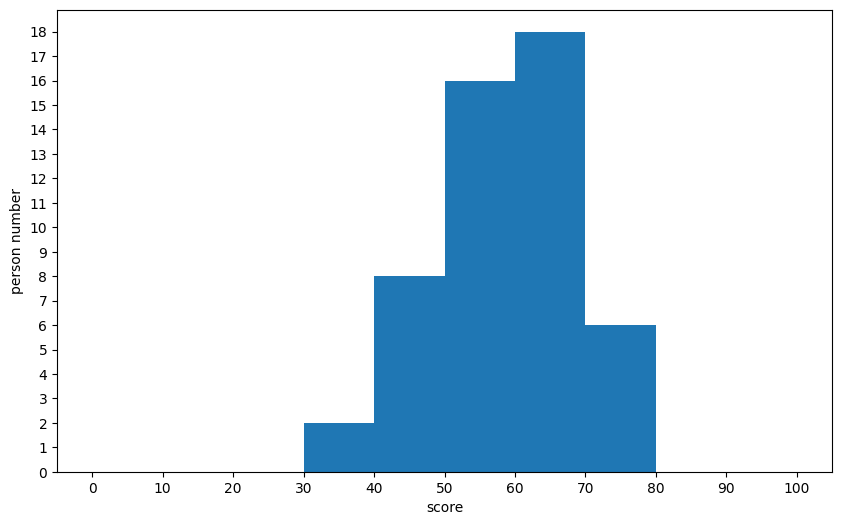

In [61]:
# 히스토그램 : 도수분포표를 막대그래프로 나타낸 것, 데이터 분포 시각적으로 파악
#             matploilib 임포트
import matplotlib.pyplot as plt

# 그래프가 주피터 노트북 위에 표시
%matplotlib inline

# 히스토그램은 hist 메서드 사용(Numpy와 동일)
fig = plt.figure(figsize = (10, 6))
ax = fig.add_subplot(111)

# 계급수를 10으로 하여 히스토그램
freq, _, _ = ax.hist(eng_scores, bins = 10, range = (0, 100))
ax.set_xlabel('score')
ax.set_xticks(np.linspace(0, 100, 10+1))
ax.set_ylabel('person number')
ax.set_yticks(np.arange(0, freq.max()+1))

plt.show()

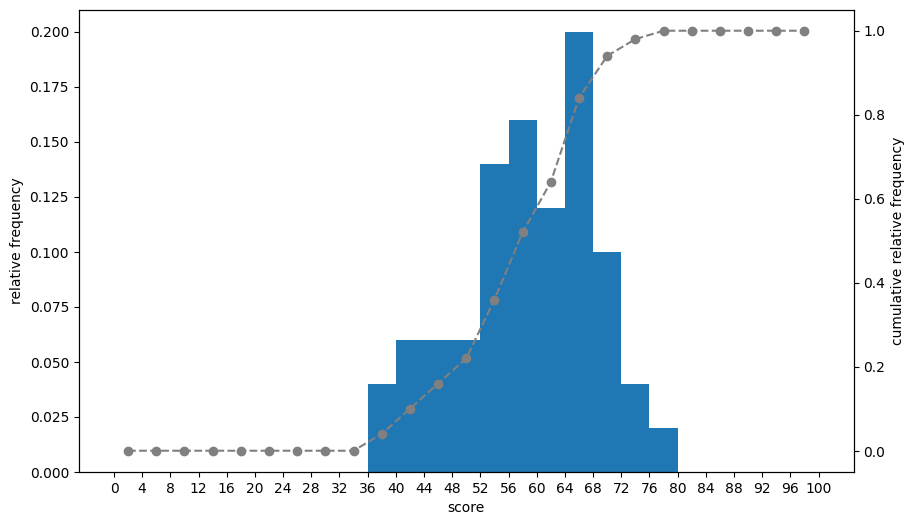

In [63]:
# 계급수 25, 계급폿 4점 히스토그램을 누적 상대도수의 꺾은선 그래프와 함께 그리기
fig = plt.figure(figsize = (10, 6))
ax1 = fig.add_subplot(111)
ax2 = ax1.twinx()

# 상대도수의 히스토그램 -> 도수 / 데이터 개수
weights = np.ones_like(eng_scores) / len(eng_scores)
rel_freq, _, _ = ax1.hist(eng_scores, bins = 25, range = (0, 100), weights = weights)
cum_rel_freq = np.cumsum(rel_freq)
class_value = [(i + (i + 4)) // 2 for i in range(0, 100, 4)]

# 꺾은선 그래프
# 인수 ls를 이용 -> '--' 점선
              # -> 마커를 'o'로 하면 점 찍기
              # -> 컬러를 '그레이'로 하면 회색
ax2.plot(class_value, cum_rel_freq, ls = '--', marker = 'o', color = 'gray')
# 꺾은선 그래프 눈금선 제거
ax2.grid(visible = False)

ax1.set_xlabel('score')
ax1.set_ylabel('relative frequency')
ax2.set_ylabel('cumulative relative frequency')
ax1.set_xticks(np.linspace(0, 100, 25+1))

plt.show()

C:\Users\Public\Documents\ESTsoft\CreatorTemp\ipykernel_2340\4127933876.py:4: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(eng_scores,  labels = ['english'])


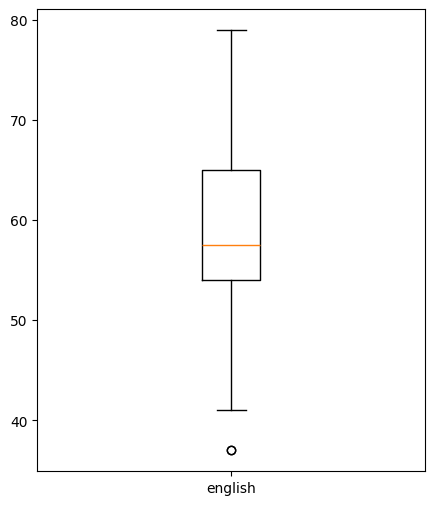

In [64]:
# 박스플롯 : 데이터 분포와 이상값 시각적으로 파악
fig = plt.figure(figsize = (5, 6))
ax = fig.add_subplot(111)
ax.boxplot(eng_scores,  labels = ['english'])

plt.show()

- +)

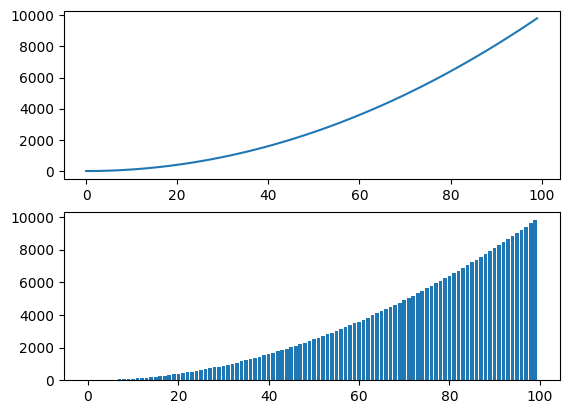

In [65]:
import matplotlib.pyplot as plt

fig = plt.figure()
ax1 = fig.add_subplot(2, 1, 1)
ax2 = fig.add_subplot(2, 1, 2)

x = range(0, 100)
y = [v * v for v in x]

ax1.plot(x, y)
ax2.bar(x, y)

plt.show()

## 연습문제

##### 첨부된 english_score_raw.csv 파일은 실제 시험 데이터에 오류, 결시, 증복, 이상값이 포함된 자료
##### 데이터를 전처리하여 분석 가능한 형태로 만들고 도수분포표(상대도수, 누적상대도수 포함)를 작성한 뒤 히스토그램과 박스플롯으로 분포 시각화

포함 항목
- score_raw를 전처리해 숫자 점수 score로 만들기(결시/미응시/N/A 처리 포함)
- 범위 밖 점수는 제거 또는 NaN 처리
- student_id 중복 시 가장 높은 점수만 남겨 정리할 것
- 계급폭 10으로 도수분포표 -> 상대도수/누적상대도수/계급값 포함
- 히스토그램(계급폭 10)을 그리고 분포의 치우침 서술
- 전체 박스플롯 + 반별 박스플롯 그리고 반별 산포도(IQR) 차이를 비교
- IQR 규칙으로 이상치 탐지하고, 이상치 리스트(student_id/반/score) 출력

In [1]:
import numpy as np
import pandas as pd
import re

pd.set_option('display.float_format', '{:.3f}'.format)

In [2]:
df = pd.read_csv('../통계분석2/받은 파일/data/english_score_raw.csv')
df

,student_id,classroom,score_raw
0,20260110,B,78.2
1,20260162,C,82.3
2,20260124,C,76.1
3,20260225,B,68.4
4,20260087,A,80.3
...,...,...,...
183,20260213,A,74.1
184,20260128,C,999
185,20260017,A,70.0점
186,20260209,A,71.4


In [3]:
df['score'] = df['score_raw'].copy()
df['score'].describe()

count       183
unique      141
top       1,002
freq          5
Name: score, dtype: object

In [12]:
type(df['score'][1])

str

In [21]:
df['score'] = df['score'].astype(str).str.replace('[점"]', '', regex=True).str.strip()
df['score'] = pd.to_numeric(df['score'], errors='coerce')
df.loc[(df['score'] < 0) | (df['score'] > 100), 'score'] = np.nan

df['score']

0     78.200
1     82.300
2     76.100
3     68.400
4     80.300
       ...  
183   74.100
184      NaN
185   70.000
186   71.400
187   75.500
Name: score, Length: 188, dtype: float64

In [24]:
for i in df['student_id']:
    if i.isdigit(df['student_id']):
        df['student_id'] = df['student_id'].distinct().max()

df

AttributeError: 'int' object has no attribute 'isdigit'